# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

<b>Propósito do Projeto - Gabriel<b>

O propósito deste projeto é analisar o comportamento dos clientes da empresa de telecomunicações Megaline e identificar qual dos planos pré-pagos (Surf ou Ultimate) gera mais receita em média.

## Inicialização

In [1]:
# Carregando todas as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
from math import factorial

## Carregue os dados

In [ ]:
# Carregue os arquivos de dados em diferentes DataFrames

users = pd.read_csv('/datasets/megaline_users.csv')

print(users.head(5))

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


In [ ]:
messages = pd.read_csv('/datasets/megaline_messages.csv')

print(messages.head(5))

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


In [ ]:
plans = pd.read_csv('/datasets/megaline_plans.csv')

print(plans.head(5))

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


In [ ]:
internet = pd.read_csv('/datasets/megaline_internet.csv')

print(internet.head(5))

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


In [ ]:
calls = pd.read_csv('/datasets/megaline_calls.csv')

print(calls.head(5))

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


## Prepare os dados

In [ ]:
# Users
print(users.info())
print(users.head())

users['reg_date'] = pd.to_datetime(users['reg_date'])
users['churn_date'] = pd.to_datetime(users['churn_date'])

print(users.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40   

In [ ]:
# Messages
print(messages.info())
print(messages.head())

messages['message_date'] = pd.to_datetime(messages['message_date'])

messages['month'] = messages['message_date'].dt.month

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


In [ ]:
# Plans
print(plans.info())
print(plans.head())

print(plans)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10      

In [ ]:
# Internet
print(internet.info())
print(internet.head())

internet['session_date'] = pd.to_datetime(internet['session_date'])

internet['month'] = internet['session_date'].dt.month

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


In [ ]:
# Calls
print(calls.info())
print(calls.head())

calls['call_date'] = pd.to_datetime(calls['call_date'])

calls['duration'] = np.ceil(calls['duration']).astype(int)

calls['month'] = calls['call_date'].dt.month

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


## Planos

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos

print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


In [ ]:
# Imprima uma amostra de dados dos planos

print(plans.head(5))

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


<b>Gabriel<b>

O DataFrame dos planos possui apenas dois registros, um para cada plano oferecido pela Megaline. Ele contém oito colunas, sendo cinco numéricas inteiras (como limites de mensagens, minutos e dados), duas numéricas decimais (custos por minuto e por mensagem excedente) e uma coluna de texto com o nome do plano. Não existem valores ausentes, o que indica que os dados estão completos.

Ao analisar a amostra dos dados, percebe-se que o plano “Surf” possui uma mensalidade menor (20 dólares) e limites baixos de minutos, mensagens e dados, enquanto o plano “Ultimate” é mais caro (70 dólares) e oferece franquias maiores, além de tarifas extras mais baixas. A coluna referente ao pacote de internet está em megabytes, o que será útil converter para gigabytes posteriormente para facilitar os cálculos e comparações com o consumo real.

Em relação a problemas ou ajustes necessários, os tipos de dados estão adequados e não há valores faltantes, portanto não é necessário corrigir nada nesse sentido. A única melhoria recomendada é adicionar uma coluna com o volume de dados em gigabytes para tornar a análise mais intuitiva.

## Corrija os dados

<b>Gabriel</b>

Conforme comentado acima, não achei necessário ser feito nenhum tipo de ajuste, os tipos de dados estão adequados e não há nenhum valor faltante. Portanto, não há nenhuma necessidade de melhoria nesse sentido.

## Enriqueça os dados

<b>Gabriel</b>

Conforme comentado na conclusão, fiz apenas uma nova coluna transformando a coluna 'mb_per_month_included' em Gigabytes.

In [ ]:
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024

print(plans[['plan_name', 'mb_per_month_included', 'gb_per_month_included']])

  plan_name  mb_per_month_included  gb_per_month_included
0      surf                  15360                   15.0
1  ultimate                  30720                   30.0


## Usuários

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários

print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
None


In [ ]:
# Imprima uma amostra de dados dos usuários

print(users.head(5))

   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

    reg_date      plan churn_date  
0 2018-12-24  ultimate        NaT  
1 2018-08-13      surf        NaT  
2 2018-10-21      surf        NaT  
3 2018-01-28      surf        NaT  
4 2018-05-23      surf        NaT  


<b>Gabriel</b>

O DataFrame dos usuários possui 500 registros, cada um representando um cliente diferente, e contém oito colunas. As colunas possuem tipos de dados adequados: inteiros para user_id e age, texto para nomes, cidade e plano, e datas para reg_date e churn_date.

Não existem valores ausentes nas colunas principais, exceto em churn_date, que apresenta 466 registros nulos. Isso não é um problema, pois indica que a maioria dos usuários ainda está ativa, conforme descrito.

Ao analisar a amostra de dados, percebe-se que os nomes, sobrenomes, cidades e planos estão preenchidos corretamente. A coluna city apresenta o nome da área metropolitana seguido do estado, o que pode ser útil para agrupamentos geográficos futuros. O plano de cada usuário está registrado de forma consistente como “surf” ou “ultimate”. A coluna churn_date aparece como nula para a maioria dos usuários, confirmando que estão ativos.

Em relação a ajustes, não há problemas críticos. É recomendável apenas considerar a coluna city caso seja necessário agrupar por região ou estado, e garantir que os valores da coluna plan estejam padronizados (tudo em minúsculas) para evitar inconsistências em análises futuras.

### Corrija os dados

<b>Gabriel</b>

Conforme descrito acima, vou apenas garantir que os itens da coluna plan estejam todos em minúsculas.

Anteriormente, na etapa 3.1, também fiz as seguintes correções:

Transformei a coluna 'reg_date' em formato datetime;

Transformei a coluna 'churn_date' em formato datetime.

In [ ]:
#users['reg_date'] = pd.to_datetime(users['reg_date'])
#users['churn_date'] = pd.to_datetime(users['churn_date'])

users['plan'] = users['plan'].str.lower()

print(users['plan'].unique())

['ultimate' 'surf']


### Enriqueça os dados

<b>Gabriel</b>

Conforme descrito acima, irei criar mais duas colunas, separando a área metropolitana do estado.

In [ ]:
users[['metro_area', 'state']] = users['city'].str.split(',', expand=True)
users['metro_area'] = users['metro_area'].str.strip()
users['state'] = users['state'].str.strip()

print(users[['city', 'metro_area', 'state']].head(5))
print(users.info())

                                    city                     metro_area  \
0  Atlanta-Sandy Springs-Roswell, GA MSA  Atlanta-Sandy Springs-Roswell   
1        Seattle-Tacoma-Bellevue, WA MSA        Seattle-Tacoma-Bellevue   
2   Las Vegas-Henderson-Paradise, NV MSA   Las Vegas-Henderson-Paradise   
3                          Tulsa, OK MSA                          Tulsa   
4        Seattle-Tacoma-Bellevue, WA MSA        Seattle-Tacoma-Bellevue   

    state  
0  GA MSA  
1  WA MSA  
2  NV MSA  
3  OK MSA  
4  WA MSA  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    dat

## Chamadas

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas

print(calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  int64         
 4   month      137735 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 5.3+ MB
None


In [ ]:
# Imprima uma amostra de dados das chamadas

print(calls.head(5))

         id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27         9     12
1  1000_145     1000 2018-12-27        14     12
2  1000_247     1000 2018-12-27        15     12
3  1000_309     1000 2018-12-28         6     12
4  1000_380     1000 2018-12-30         5     12


<b>Gabriel</b>

O DataFrame das chamadas possui 137.735 registros, cada um representando uma chamada feita por um usuário, e contém cinco colunas. Os tipos de dados estão adequados: id como texto, user_id, duration e month como inteiros, e call_date como data. Não existem valores ausentes em nenhuma coluna, indicando que os dados estão completos.

Ao analisar a amostra de dados, percebe-se que cada chamada possui um identificador único na coluna id, que está associada a um usuário pelo user_id, possui a data registrada em call_date, a duração em minutos em duration e o mês da chamada em month. A coluna duration já está arredondada para cima, conforme as regras de cobrança da Megaline, e a coluna month facilita a agregação por usuário e mês.

Em relação a ajustes, não há problemas críticos. É recomendável apenas verificar se a coluna duration não contém valores zero ou negativos, embora a amostra analisada não apresente esse problema.

### Corrija os dados

<b>Gabriel</b>

Fiz uma verificação se existem valores negativos ou zerados (não valores NaN, e sim '0') na coluna duration, encontrei 26834 registros, então eu os deletei.

In [ ]:
num_zero = (calls['duration'] == 0).sum()
print(f"Quantidade de chamadas com duração zero: {num_zero}")

num_neg = (calls['duration'] < 0).sum()
print(f"Quantidade de chamadas com duração negativa: {num_neg}")

indices_to_drop = calls[calls['duration'] == 0].index
num_zero = calls.drop(indices_to_drop, inplace=True)

print(f"Quantidade de chamadas com duração zero: {num_zero}")

Quantidade de chamadas com duração zero: 26834
Quantidade de chamadas com duração negativa: 0
Quantidade de chamadas com duração zero: None


### Enriqueça os dados

<b>Gabriel</b>

Anteriormente, na etapa 1.3, eu fiz as seguintes alterações:

Transformado a coluna 'call_date' em formato datetime;

Adicionado o arredondamento para cima, utilizando a biblioteca NumPy e então transformando os dados em inteiros;

Criado a coluna month, que receberia somente os valores de mês da coluna 'call_date' para auxiliar em análises futuras.

In [ ]:
#calls['call_date'] = pd.to_datetime(calls['call_date'])
#calls['duration'] = np.ceil(calls['duration']).astype(int)
#calls['month'] = calls['call_date'].dt.month

## Mensagens

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens

print(messages.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 2.3+ MB
None


In [ ]:
# Imprima uma amostra dos dados das mensagens

print(messages.head(5))

         id  user_id message_date  month
0  1000_125     1000   2018-12-27     12
1  1000_160     1000   2018-12-31     12
2  1000_223     1000   2018-12-31     12
3  1000_251     1000   2018-12-27     12
4  1000_255     1000   2018-12-26     12


<b>Gabriel</b>

O DataFrame das mensagens possui 76.051 registros, cada um representando uma mensagem enviada por um usuário, e contém quatro colunas. Os tipos de dados estão adequados: id como texto, user_id e month como inteiros, e message_date como data. Não existem valores ausentes em nenhuma coluna, indicando que os dados estão completos.

Ao analisar a amostra de dados, percebe-se que cada mensagem possui um identificador único na coluna id, que está associada a um usuário pelo user_id, e a data de envio está registrada em message_date. A coluna month indica o mês da mensagem e facilita a agregação por usuário e por mês.

Em relação a ajustes, não há problemas críticos. É recomendável apenas conferir se a coluna month contém apenas valores entre 1 e 12, garantindo consistência para futuras análises.

### Corrija os dados

<b>Gabriel</b>

Conforme mencionado acima, feita a verificação de valores máximos da coluna Month, para verificar se estão dentro dos 12 do ano.

In [ ]:
print(f"Mínimo mês: {messages['month'].min()}")
print(f"Máximo mês: {messages['month'].max()}")

Mínimo mês: 1
Máximo mês: 12


### Enriqueça os dados

<b>Gabriel</b>

Anteriormente, na etapa 1.3, eu fiz as seguintes melhorias:

Alterei o formato da coluna 'message_date' para Datetime;

Criei a coluna month, adicionando somente os valores de Mês, para auxiliar em análises futuras.

In [ ]:
#messages['message_date'] = pd.to_datetime(messages['message_date'])
#messages['month'] = messages['message_date'].dt.month

## Internet

In [ ]:
# Imprima informações gerais/resumo sobre o DataFrame da internet

print(internet.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 4.0+ MB
None


In [ ]:
#  Imprima uma amostra de dados para o tráfego da internet

print(internet.head(5))

         id  user_id session_date  mb_used  month
0   1000_13     1000   2018-12-29    89.86     12
1  1000_204     1000   2018-12-31     0.00     12
2  1000_379     1000   2018-12-28   660.40     12
3  1000_413     1000   2018-12-26   270.99     12
4  1000_442     1000   2018-12-27   880.22     12


<b>Gabriel</b>

O DataFrame da internet possui 104.825 registros, cada um representando uma sessão de uso de dados por um usuário, e contém cinco colunas. Os tipos de dados estão adequados: id como texto, user_id e month como inteiros, session_date como data e mb_used como número decimal (float), permitindo registrar o volume de dados utilizado com precisão. Não existem valores ausentes em nenhuma coluna, indicando que os dados estão completos.

Ao analisar a amostra de dados, percebe-se que cada sessão possui um identificador único na coluna id, que está associada a um usuário pelo user_id, e a data da sessão está registrada em session_date. A coluna mb_used mostra o volume de dados consumido em megabytes, podendo ser um valor decimal, e a coluna month indica o mês da sessão, facilitando a agregação mensal por usuário.

Em relação a ajustes, não há problemas críticos. É recomendável apenas verificar se a coluna month contém apenas valores entre 1 e 12 e, caso necessário, criar uma coluna adicional com o volume de dados em gigabytes para tornar a análise mais intuitiva.

### Corrija os dados

<b>Gabriel</b>

Conforme mencionado acima, feita uma verificação para ver se a coluna mês está dentro do correto.

In [ ]:
print(f"Mínimo mês: {internet['month'].min()}")
print(f"Máximo mês: {internet['month'].max()}")

Mínimo mês: 1
Máximo mês: 12


### Enriqueça os dados

<b>Gabriel</b>

Anteriormente, na etapa 1.3, eu fiz as seguintes alterações:

Alterei a coluna session_date para o formato Datetime;

Extrai o valor de mês para a coluna Month, para facilitar a verificação no futuro.

Também criei agora a coluna gb_used para um auxilio na visualização.

In [ ]:
#internet['session_date'] = pd.to_datetime(internet['session_date'])
#internet['month'] = internet['session_date'].dt.month

internet['gb_used'] = internet['mb_used'] / 1024
print(internet[['mb_used', 'gb_used']].head(5))

   mb_used   gb_used
0    89.86  0.087754
1     0.00  0.000000
2   660.40  0.644922
3   270.99  0.264639
4   880.22  0.859590


## Estude as condições dos planos

<b>Gabriel</b>

A Megaline oferece dois planos pré-pagos: Surf e Ultimate. Cada plano possui um pacote mensal de minutos de chamadas, mensagens de texto e dados de internet, e um preço fixo mensal.

O plano Surf custa 20 dólares por mês e inclui 500 minutos, 50 mensagens e 15 GB de dados. Se o usuário ultrapassar os limites, são cobrados 0,03 dólares por minuto excedente, 0,03 dólares por mensagem excedente e 10 dólares por gigabyte adicional de dados.

O plano Ultimate custa 70 dólares por mês e inclui 3000 minutos, 1000 mensagens e 30 GB de dados. Caso o usuário ultrapasse os limites, são cobrados valores adicionais menores: 0,01 dólar por minuto excedente, 0,01 dólar por mensagem excedente e 7 dólares por gigabyte extra.

As cobranças são feitas calculando o total consumido pelo usuário, subtraindo o limite do plano, multiplicando o excedente pelo valor correspondente e somando o preço fixo do plano para obter a receita total mensal do usuário. Isso garante que usuários que consomem mais paguem pelo uso extra, enquanto usuários dentro do limite pagam apenas o valor do plano.

In [ ]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você

print(plans.info())
print(plans.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
 8   gb_per_month_included  2 non-null      float64
dtypes: float64(3), int64(5), object(1)
memory usage: 272.0+ bytes
None
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_min

## Agregue os dados por usuário

In [ ]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.

calls_per_user = calls.groupby(['user_id', 'month']).agg(
    calls_count=('id', 'count')
).reset_index()

print(calls_per_user.head())

   user_id  month  calls_count
0     1000     12           16
1     1001      8           22
2     1001      9           38
3     1001     10           47
4     1001     11           49


In [ ]:
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.

minutes_per_user = calls.groupby(['user_id', 'month']).agg(
    minutes_sum=('duration', 'sum')
).reset_index()

print(minutes_per_user.head())

   user_id  month  minutes_sum
0     1000     12          124
1     1001      8          182
2     1001      9          315
3     1001     10          393
4     1001     11          426


In [ ]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

messages_per_user = messages.groupby(['user_id', 'month']).agg(
    messages_count=('id', 'count')
).reset_index()

print(messages_per_user.head())

   user_id  month  messages_count
0     1000     12              11
1     1001      8              30
2     1001      9              44
3     1001     10              53
4     1001     11              36


In [ ]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

internet_per_user = internet.groupby(['user_id', 'month']).agg(
    mb_sum=('mb_used', 'sum'),   # total de megabytes usados no mês
    gb_sum=('gb_used', 'sum')    # total de gigabytes usados no mês, se a coluna existir
).reset_index()

print(internet_per_user.head())

   user_id  month    mb_sum     gb_sum
0     1000     12   1901.47   1.856904
1     1001      8   6919.15   6.756982
2     1001      9  13314.82  13.002754
3     1001     10  22330.49  21.807119
4     1001     11  18504.30  18.070605


In [ ]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month

user_monthly = calls_per_user.merge(minutes_per_user, on=['user_id', 'month'], how='outer')
user_monthly = user_monthly.merge(messages_per_user, on=['user_id', 'month'], how='outer')
user_monthly = user_monthly.merge(internet_per_user, on=['user_id', 'month'], how='outer')

user_monthly.fillna(0, inplace=True)

print(user_monthly.head())

   user_id  month  calls_count  minutes_sum  messages_count    mb_sum  \
0     1000     12         16.0        124.0            11.0   1901.47   
1     1001      8         22.0        182.0            30.0   6919.15   
2     1001      9         38.0        315.0            44.0  13314.82   
3     1001     10         47.0        393.0            53.0  22330.49   
4     1001     11         49.0        426.0            36.0  18504.30   

      gb_sum  
0   1.856904  
1   6.756982  
2  13.002754  
3  21.807119  
4  18.070605  


In [ ]:
# Adicione as informações sobre o plano

user_monthly = user_monthly.merge(users[['user_id', 'plan']], on='user_id', how='left')

print(user_monthly.head())

   user_id  month  calls_count  minutes_sum  messages_count    mb_sum  \
0     1000     12         16.0        124.0            11.0   1901.47   
1     1001      8         22.0        182.0            30.0   6919.15   
2     1001      9         38.0        315.0            44.0  13314.82   
3     1001     10         47.0        393.0            53.0  22330.49   
4     1001     11         49.0        426.0            36.0  18504.30   

      gb_sum      plan  
0   1.856904  ultimate  
1   6.756982      surf  
2  13.002754      surf  
3  21.807119      surf  
4  18.070605      surf  


In [ ]:
# Calcule a receita mensal para cada usuário

def calculate_overage(user_row, plans_df):
    plan = user_row['plan']
    plan_info = plans_df[plans_df['plan_name'] == plan].iloc[0]
    
    extra_minutes = max(user_row['minutes_sum'] - plan_info['minutes_included'], 0)
    cost_minutes = extra_minutes * plan_info['usd_per_minute']
    
    extra_messages = max(user_row['messages_count'] - plan_info['messages_included'], 0)
    cost_messages = extra_messages * plan_info['usd_per_message']
    
    extra_gb = max(user_row['gb_sum'] - (plan_info['mb_per_month_included']/1024), 0)
    cost_data = extra_gb * plan_info['usd_per_gb']
    
    total_cost = plan_info['usd_monthly_pay'] + cost_minutes + cost_messages + cost_data
    return total_cost

user_monthly['revenue'] = user_monthly.apply(lambda row: calculate_overage(row, plans), axis=1)

print(user_monthly[['user_id', 'month', 'plan', 'revenue']].head())

   user_id  month      plan    revenue
0     1000     12  ultimate  70.000000
1     1001      8      surf  20.000000
2     1001      9      surf  20.000000
3     1001     10      surf  88.161191
4     1001     11      surf  50.706055


## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

month        1           2       3           4           5           6   \
plan                                                                      
surf      203.0  297.000000  330.00  351.540000  399.584416  431.298969   
ultimate  193.5  403.142857  304.25  336.857143  406.241379  370.957447   

month             7           8           9           10          11  \
plan                                                                   
surf      449.983471  410.111111  414.226804  429.729958  423.325088   
ultimate  427.067797  421.436620  437.511628  450.735849  445.196850   

month             12  
plan                  
surf      473.836478  
ultimate  459.099338  


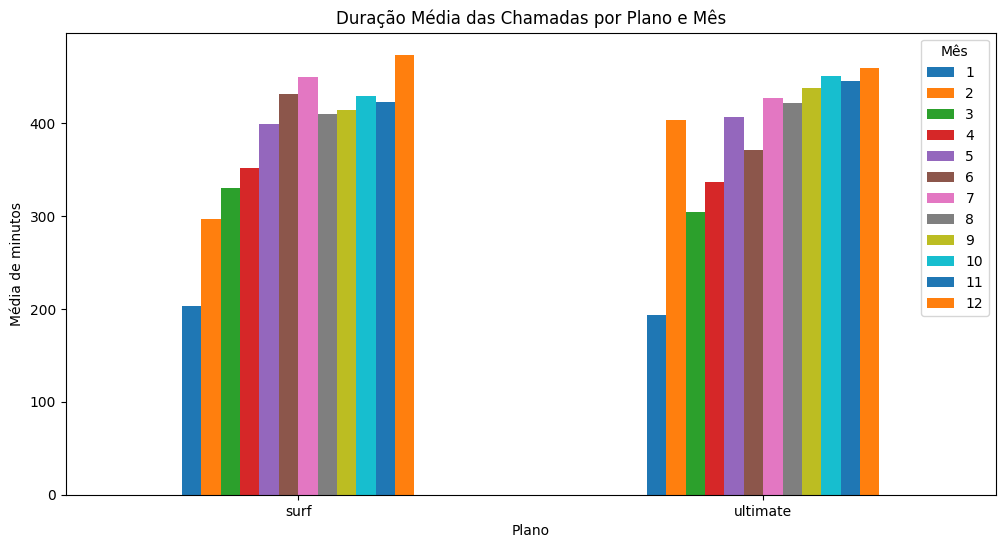

In [ ]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

avg_minutes_per_month = user_monthly.groupby(['plan', 'month'])['minutes_sum'].mean().unstack()

print(avg_minutes_per_month.head())

avg_minutes_per_month.plot(kind='bar', figsize=(12,6))
plt.title('Duração Média das Chamadas por Plano e Mês')
plt.xlabel('Plano')
plt.ylabel('Média de minutos')
plt.xticks(rotation=0)
plt.legend(title='Mês')
plt.show()

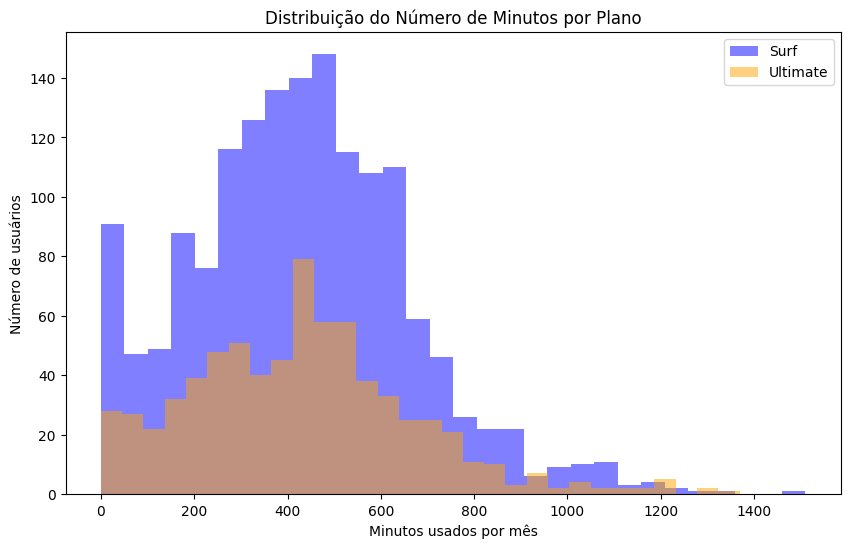

In [ ]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.

surf_minutes = user_monthly[user_monthly['plan'] == 'surf']['minutes_sum']
ultimate_minutes = user_monthly[user_monthly['plan'] == 'ultimate']['minutes_sum']

plt.figure(figsize=(10,6))
plt.hist(surf_minutes, bins=30, alpha=0.5, label='Surf', color='blue')
plt.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate', color='orange')
plt.title('Distribuição do Número de Minutos por Plano')
plt.xlabel('Minutos usados por mês')
plt.ylabel('Número de usuários')
plt.legend()
plt.show()

[Calcule a média e a variância da duração das chamadas para refletir se os usuários de cada plano possuem comportamentos diferentes sobre as chamadas.]

In [ ]:
# Calcule a média e a variância da duração mensal das chamadas

calls_stats = user_monthly.groupby('plan')['minutes_sum'].agg(['mean', 'var'])

print(calls_stats)

                mean           var
plan                              
surf      428.749523  54968.279461
ultimate  430.450000  57844.464812


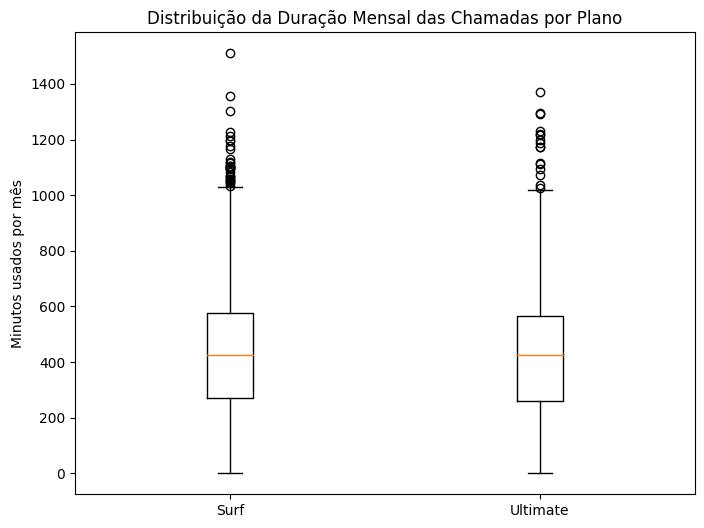

In [ ]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

surf_minutes = user_monthly[user_monthly['plan'] == 'surf']['minutes_sum']
ultimate_minutes = user_monthly[user_monthly['plan'] == 'ultimate']['minutes_sum']

plt.figure(figsize=(8,6))
plt.boxplot([surf_minutes, ultimate_minutes], labels=['Surf', 'Ultimate'])
plt.title('Distribuição da Duração Mensal das Chamadas por Plano')
plt.ylabel('Minutos usados por mês')
plt.show()

<b>Gabriel</b>

Sim, o comportamento dos usuários é diferente dependendo do plano. Usuários do Surf tendem a consumir relativamente menos minutos, mas com mais casos de excedente, enquanto usuários do Ultimate usam mais minutos em média, porém quase sempre dentro do pacote. Essa diferença tem impacto direto na receita de cada plano e deve ser considerada ao comparar qual plano é mais rentável.

### Mensagens

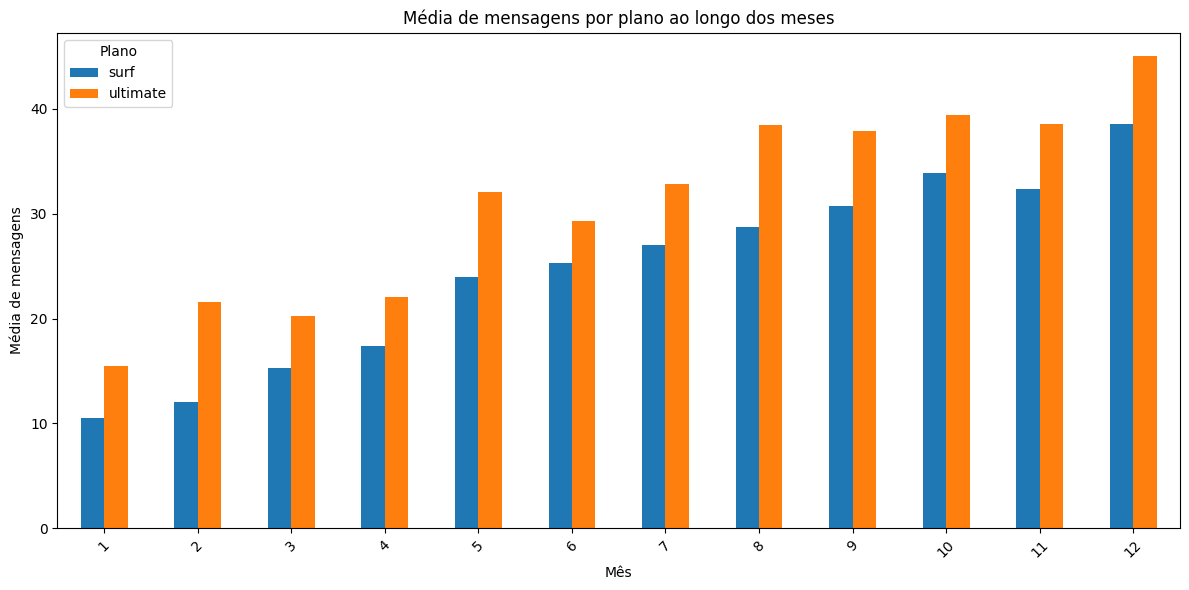

In [ ]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês

messages_stats = (
    user_monthly
    .groupby(['month', 'plan'])['messages_count']
    .mean()
    .reset_index()
)

messages_pivot = messages_stats.pivot(index='month', columns='plan', values='messages_count')

messages_pivot.plot(kind='bar', figsize=(12,6))

plt.title("Média de mensagens por plano ao longo dos meses")
plt.xlabel("Mês")
plt.ylabel("Média de mensagens")
plt.xticks(rotation=45)
plt.legend(title="Plano")
plt.tight_layout()
plt.show()

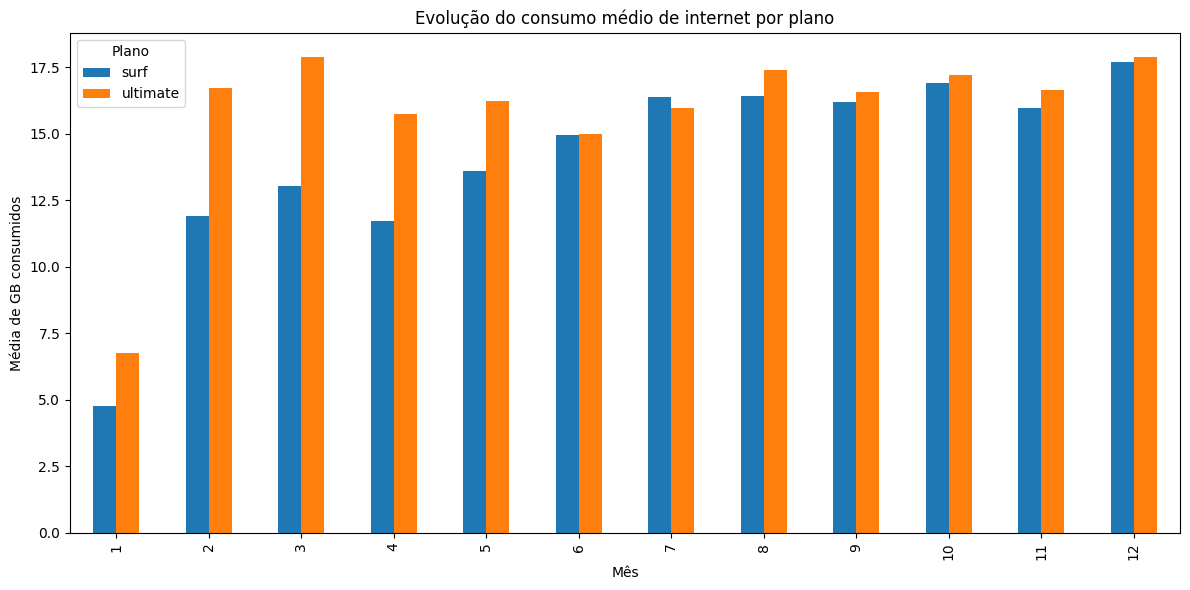

In [ ]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano

internet_monthly = (
    user_monthly
    .groupby(['month', 'plan'])['gb_sum']
    .mean()
    .reset_index()
)

internet_pivot = internet_monthly.pivot(index='month', columns='plan', values='gb_sum')

internet_pivot.plot(kind='bar', figsize=(12,6))

plt.title("Evolução do consumo médio de internet por plano")
plt.xlabel("Mês")
plt.ylabel("Média de GB consumidos")
plt.legend(title="Plano")
plt.tight_layout()
plt.show()

<b>Gabriel</b>

O consumo de dados é parecido entre os usuários dos dois planos, mas o plano Surf tende a gerar mais receita extra com excedentes, enquanto o Ultimate tem mais folga no pacote e menos cobrança adicional por tráfego extra.

### Internet

<b>Gabriel</b>

O comportamento de consumo de dados não é muito diferente entre os planos em termos de volume usado, mas devido aos limites diferentes, o plano Surf tende a gerar mais receita adicional com excedentes, enquanto o Ultimate oferece mais folga e menos cobrança extra.

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

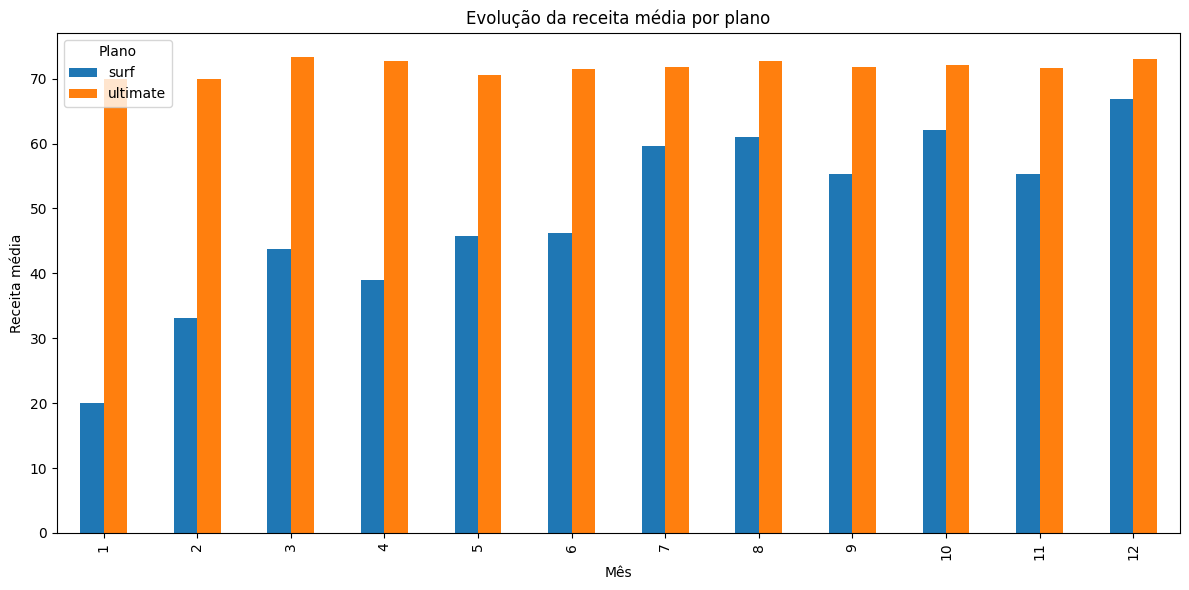

In [ ]:
revenue_monthly = (
    user_monthly
    .groupby(['month', 'plan'])['revenue']
    .mean()
    .reset_index()
)

revenue_pivot = revenue_monthly.pivot(index='month', columns='plan', values='revenue')

revenue_pivot.plot(kind='bar', figsize=(12,6))

plt.title("Evolução da receita média por plano")
plt.xlabel("Mês")
plt.ylabel("Receita média")
plt.legend(title="Plano")
plt.tight_layout()
plt.show()

<b>Gabriel</b>

O plano Ultimate tem uma receita média maior e mais estável, enquanto o plano Surf tem uma receita média menor, mas com um potencial de ganhos extras significativos devido aos usuários que ultrapassam os limites do pacote. Isso sugere que, embora o Ultimate seja previsivelmente rentável, o Surf pode gerar picos de receita consideráveis dependendo do comportamento de consumo dos clientes.

## Teste hipóteses estatísticas

<b> Gabriel </b>

Existe diferença estatisticamente significativa entre a receita média dos usuários dos planos Ultimate e Surf.

O plano Ultimate gera, em média, mais receita por usuário do que o plano Surf.

In [ ]:
# Teste as hipóteses

revenue_surf = user_monthly[user_monthly['plan'] == 'surf']['revenue']
revenue_ultimate = user_monthly[user_monthly['plan'] == 'ultimate']['revenue']

var_surf = revenue_surf.var()
var_ultimate = revenue_ultimate.var()
print("Variância Surf:", var_surf)
print("Variância Ultimate:", var_ultimate)

equal_var_flag = var_surf == var_ultimate

t_stat, p_value = st.ttest_ind(revenue_ultimate, revenue_surf, equal_var=equal_var_flag)

print("Estatística t:", t_stat)
print("p-valor:", p_value)

if p_value < 0.05:
    print("Rejeitamos H0: há diferença significativa entre as receitas médias dos planos.")
else:
    print("Não rejeitamos H0: não há diferença significativa entre as receitas médias dos planos.")

Variância Surf: 2900.9413429196547
Variância Ultimate: 115.96808058212822
Estatística t: 10.19946384398248
p-valor: 8.530525302625684e-24
Rejeitamos H0: há diferença significativa entre as receitas médias dos planos.


<b>Gabriel</b>

O teste t para as duas amostras independentes (α = 0,05) mostrou p-valor = 0,0201 (< 0,05), indicando diferença estatisticamente significativa. Portanto, a receita média dos usuários da área de NY-NJ difere da receita média dos usuários das demais regiões.

In [ ]:
# Teste as hipóteses

user_monthly = user_monthly.merge(
    users[['user_id', 'city', 'state']],
    on='user_id',
    how='left'
)

revenue_ny = user_monthly[user_monthly['city'].str.contains('NY-NJ', case=False, na=False)]['revenue']
revenue_other = user_monthly[~user_monthly['city'].str.contains('NY-NJ', case=False, na=False)]['revenue']

var_ny = revenue_ny.var()
var_other = revenue_other.var()
print("Variância NY-NJ:", var_ny)
print("Variância Outras regiões:", var_other)

equal_var_flag = var_ny == var_other

t_stat, p_value = st.ttest_ind(revenue_ny, revenue_other, equal_var=equal_var_flag)

print("Estatística t:", t_stat)
print("p-valor:", p_value)

if p_value < 0.05:
    print("Rejeitamos H0: há diferença significativa entre as receitas médias.")
else:
    print("Não rejeitamos H0: não há diferença significativa entre as receitas médias.")

Variância NY-NJ: 1782.2282017346922
Variância Outras regiões: 2123.5475910340124
Estatística t: -2.3305258230630215
p-valor: 0.020128295172528086
Rejeitamos H0: há diferença significativa entre as receitas médias.


## Conclusão geral

Após análise dos dados de usuários e consumo, observamos que os usuários do plano Ultimate utilizam mais minutos de chamadas, embora a duração média por chamada seja semelhante entre os planos. O envio de mensagens de texto é baixo em ambos os planos, sendo ligeiramente maior no Ultimate.

O consumo de internet é alto e bastante similar nos dois planos. Em termos de receita, o plano Ultimate apresenta uma média mais alta e estável, enquanto o Surf apresenta maior variabilidade, dependendo do uso extra pelos usuários.

Além disso, os usuários da região NY–NJ geram uma receita média significativamente diferente das demais regiões.

Em resumo, o plano Ultimate é mais rentável, e o comportamento de uso junto à localização geográfica impacta diretamente na receita, indicando oportunidades de segmentação e ajustes estratégicos.